In [ ]:
!pip install geopandas imageio[ffmpeg] --quiet

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import imageio.v2 as imageio
import geopandas as gpd
from IPython.display import Image, display
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

os.makedirs('graficos', exist_ok=True)
os.makedirs('gif', exist_ok=True)

BG_COLOR = '#0d1b2a'
TEXT_COLOR = 'white'
LINE_COLOR = '#00b4d8'

In [ ]:

df_raw = pd.read_csv('DATASET_DENUNCIAS.csv', encoding='latin1', sep=None, engine='python')
df_raw.columns = df_raw.columns.str.strip().str.upper()

rename_map = {
    'AÑO': 'ANIO',
    'PROVINCIA': 'PROV_HECHO',
    'MODALIDAD': 'P_MODALIDADES',
    'CANTIDAD': 'cantidad'
}
df = df_raw.rename(columns=rename_map).copy()

df['P_MODALIDADES'] = df['P_MODALIDADES'].astype(str).str.strip().str.title()
df['P_MODALIDADES'] = df['P_MODALIDADES'].str.replace('Ã³', 'ó').str.replace('Ã', 'í')
df['PROV_HECHO'] = df['PROV_HECHO'].astype(str).str.strip().str.title()

df['ANIO'] = pd.to_numeric(df['ANIO'], errors='coerce').fillna(0).astype(int)
df['cantidad'] = pd.to_numeric(df['cantidad'], errors='coerce').fillna(0).astype(int)

print(f'✅ Dataset procesado: {len(df):,} registros.')

✅ Dataset procesado: 15,814 registros.


In [ ]:
# 1. Evolución Histórica
por_anio = df.groupby('ANIO')['cantidad'].sum().reset_index()
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)
ax.fill_between(por_anio['ANIO'], por_anio['cantidad'], alpha=0.25, color=LINE_COLOR)
ax.plot(por_anio['ANIO'], por_anio['cantidad'], color=LINE_COLOR, linewidth=2.5, marker='o')
for x, y in zip(por_anio['ANIO'], por_anio['cantidad']):
    ax.annotate(f'{y:,}', (x, y), textcoords='offset points', xytext=(0, 10), ha='center', color=TEXT_COLOR, fontsize=9)
ax.set_title('Evolución de Denuncias Policiales en Cajamarca', color=TEXT_COLOR, fontsize=14, fontweight='bold', pad=15)
ax.tick_params(colors=TEXT_COLOR)
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color('#333')
ax.set_xticks(por_anio['ANIO'])
plt.savefig('graficos/01_evolucion_total.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.close()

# 2. Mapa de Calor Provincia vs Año
pivot_prov = df.groupby(['PROV_HECHO', 'ANIO'])['cantidad'].sum().reset_index().pivot(index='PROV_HECHO', columns='ANIO', values='cantidad').fillna(0)
pivot_prov = pivot_prov.loc[pivot_prov.sum(axis=1).sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(BG_COLOR)
sns.heatmap(pivot_prov, cmap='YlOrRd', annot=True, fmt='.0f', linewidths=0.5, linecolor=BG_COLOR, ax=ax, cbar_kws={'label': 'Denuncias'})
ax.set_title('Concentración de Denuncias por Provincia y Año', color=TEXT_COLOR, fontsize=13, fontweight='bold', pad=15)
ax.tick_params(colors=TEXT_COLOR)
ax.set_ylabel('')
ax.set_xlabel('')
plt.savefig('graficos/03_heatmap_provincias.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.close()

print('✅ Gráficos estáticos exportados.')

✅ Gráficos estáticos exportados.


In [ ]:
display(mapa_peru.columns)

Index(['COUNT', 'FIRST_IDPR', 'NOMBPROV', 'FIRST_NOMB', 'LAST_DCTO',
       'LAST_LEY', 'FIRST_FECH', 'LAST_FECHA', 'MIN_SHAPE_', 'ha', 'geometry'],
      dtype='object')

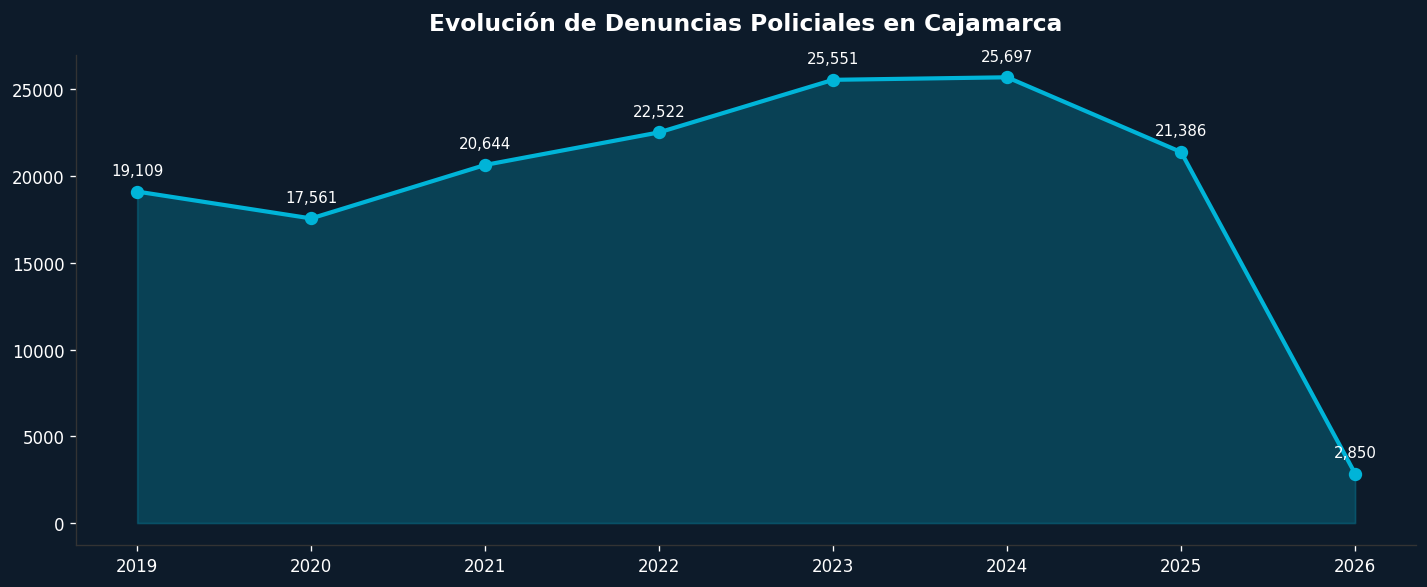

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import numpy as np
import os

os.makedirs('graficos', exist_ok=True)

BG_COLOR = '#0d1b2a'
TEXT_COLOR = 'white'
LINE_COLOR = '#00b4d8'

por_anio = df.groupby('ANIO')['cantidad'].sum().reset_index()
años = por_anio['ANIO'].values
totales = por_anio['cantidad'].values

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

ax.fill_between(años, totales, alpha=0.25, color=LINE_COLOR)
ax.plot(años, totales, color=LINE_COLOR, linewidth=2.5, marker='o', markersize=7)

for x, y in zip(años, totales):
    ax.annotate(f'{y:,}', (x, y), textcoords='offset points', xytext=(0, 10), ha='center', color=TEXT_COLOR, fontsize=9)

ax.set_title('Evolución de Denuncias Policiales en Cajamarca', color=TEXT_COLOR, fontsize=14, fontweight='bold', pad=15)
ax.tick_params(colors=TEXT_COLOR)
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color('#333')
ax.set_xticks(años)

plt.tight_layout()
plt.savefig('graficos/01_evolucion_total.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

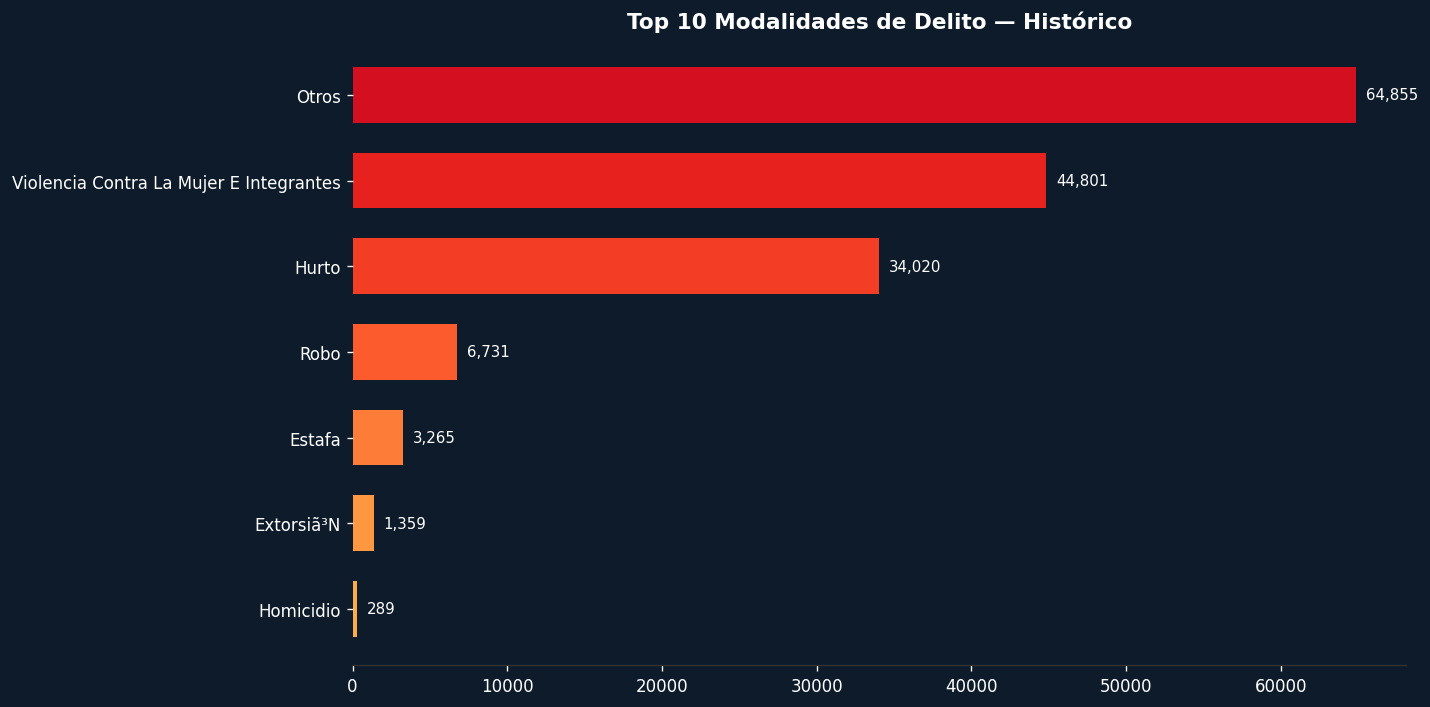

In [ ]:
top10 = df.groupby('P_MODALIDADES')['cantidad'].sum().sort_values().tail(10)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

bars = ax.barh(top10.index, top10.values, color=plt.cm.YlOrRd(np.linspace(0.4, 1.0, 10)), height=0.65)

for bar, val in zip(bars, top10.values):
    ax.text(bar.get_width() + top10.values.max() * 0.01, bar.get_y() + bar.get_height() / 2, f'{val:,}', va='center', color=TEXT_COLOR, fontsize=9)

ax.set_title('Top 10 Modalidades de Delito — Histórico', color=TEXT_COLOR, fontsize=13, fontweight='bold')
ax.tick_params(colors=TEXT_COLOR)
ax.spines[['top','right','left']].set_visible(False)
ax.spines['bottom'].set_color('#333')

plt.tight_layout()
plt.savefig('graficos/02_top10_modalidades.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

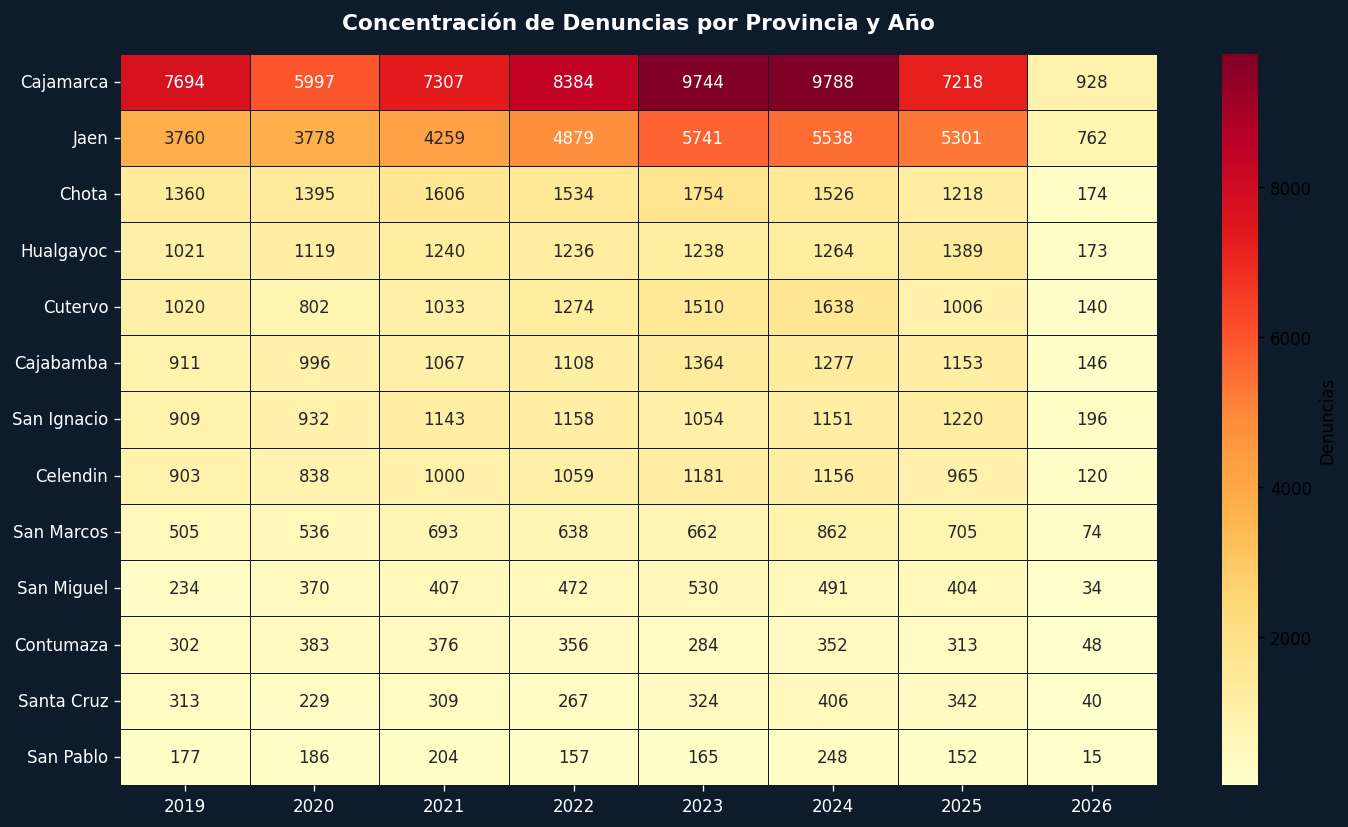

In [ ]:
pivot_prov = df.groupby(['PROV_HECHO', 'ANIO'])['cantidad'].sum().reset_index().pivot(index='PROV_HECHO', columns='ANIO', values='cantidad').fillna(0)
pivot_prov = pivot_prov.loc[pivot_prov.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

sns.heatmap(pivot_prov, cmap='YlOrRd', annot=True, fmt='.0f', linewidths=0.5, linecolor=BG_COLOR, ax=ax, cbar_kws={'label': 'Denuncias'})

ax.set_title('Concentración de Denuncias por Provincia y Año', color=TEXT_COLOR, fontsize=13, fontweight='bold', pad=15)
ax.tick_params(colors=TEXT_COLOR)
ax.set_ylabel('')
ax.set_xlabel('')

plt.tight_layout()
plt.savefig('graficos/03_heatmap_provincias.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import imageio.v2 as imageio
from IPython.display import Image, display


os.makedirs('gif', exist_ok=True)

BG_COLOR = '#1e1e1e'
TEXT_COLOR = '#ffffff'

AÑOS = sorted(df['ANIO'].unique())
PROVINCIAS = sorted(df['PROV_HECHO'].unique())


PALETTE = plt.cm.tab20(np.linspace(0, 1, len(PROVINCIAS)))
COLOR_MAP = dict(zip(PROVINCIAS, PALETTE))


def crear_gif_modalidad(modalidad_filtro, nombre_gif, top_n=10):
    frames = []


    max_val_for_xlim = 0
    for anio_temp in AÑOS:
        if modalidad_filtro:
            datos_anio_temp = df[
                (df['ANIO'] == anio_temp) &
                (df['P_MODALIDADES'].str.contains(modalidad_filtro, case=False, na=False))
            ]
        else:
            datos_anio_temp = df[df['ANIO'] == anio_temp]

        if not datos_anio_temp.empty:
            ranking_temp = datos_anio_temp.groupby('PROV_HECHO')['cantidad'].sum().sort_values(ascending=True).tail(top_n)
            if not ranking_temp.empty:
                current_max = ranking_temp.max()
                if current_max > max_val_for_xlim:
                    max_val_for_xlim = current_max
    max_val_for_xlim = (max_val_for_xlim * 1.2) if max_val_for_xlim > 0 else 100

    for año in AÑOS:

        if modalidad_filtro:
            datos_año = df[
                (df['ANIO'] == año) &
                (df['P_MODALIDADES'].str.contains(modalidad_filtro, case=False, na=False))
            ]
        else:
            datos_año = df[df['ANIO'] == año]


        ranking = datos_año.groupby('PROV_HECHO')['cantidad'].sum().sort_values(ascending=True).tail(top_n)

        fig, ax = plt.subplots(figsize=(10, 6))
        fig.patch.set_facecolor(BG_COLOR)
        ax.set_facecolor(BG_COLOR)

        if not ranking.empty:
            colores = [COLOR_MAP.get(p, '#aaa') for p in ranking.index]
            bars = ax.barh(ranking.index, ranking.values, color=colores, height=0.7, edgecolor='none')

            for bar, val in zip(bars, ranking.values):
                ax.text(bar.get_width() + max_val_for_xlim * 0.01, bar.get_y() + bar.get_height() / 2,
                        f'{val:,}', va='center', ha='left', color=TEXT_COLOR, fontsize=9.5, fontweight='bold')
        else:

            ax.set_yticks(range(top_n))
            ax.set_yticklabels([''] * top_n)
            ax.tick_params(axis='y', length=0)

        titulo = modalidad_filtro if modalidad_filtro else 'Total de Delitos'
        ax.set_title(f'Cajamarca — {titulo}\nDenuncias por provincia',
                     color=TEXT_COLOR, fontsize=12, fontweight='bold', loc='left', pad=10)


        ax.text(0.97, 0.05, str(año), transform=ax.transAxes,
                fontsize=42, color=TEXT_COLOR, alpha=0.15, ha='right', va='bottom', fontweight='bold')

        ax.set_xlim(0, max_val_for_xlim)
        ax.tick_params(colors=TEXT_COLOR, labelsize=9)
        ax.spines[['top', 'right', 'left']].set_visible(False)
        ax.spines['bottom'].set_color('#333')
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

        plt.tight_layout()
        ruta_frame = f'gif/frame_{año}_{nombre_gif}.png'
        plt.savefig(ruta_frame, dpi=120, facecolor=BG_COLOR)
        plt.close()
        frames.append(ruta_frame)

    if not frames:
        print(f'⚠️ No se encontraron datos para: {modalidad_filtro}')
        return None

    imagenes = [imageio.imread(f) for f in frames]
    ruta_gif = f'gif/{nombre_gif}.gif'
    imageio.mimwrite(ruta_gif, imagenes, fps=1.2, loop=0)

    for f in frames:
        os.remove(f)

    print(f'✅ GIF creado exitosamente: {ruta_gif}')
    return ruta_gif

✅ GIF creado exitosamente: gif/Total_Denuncias_Cajamarca.gif


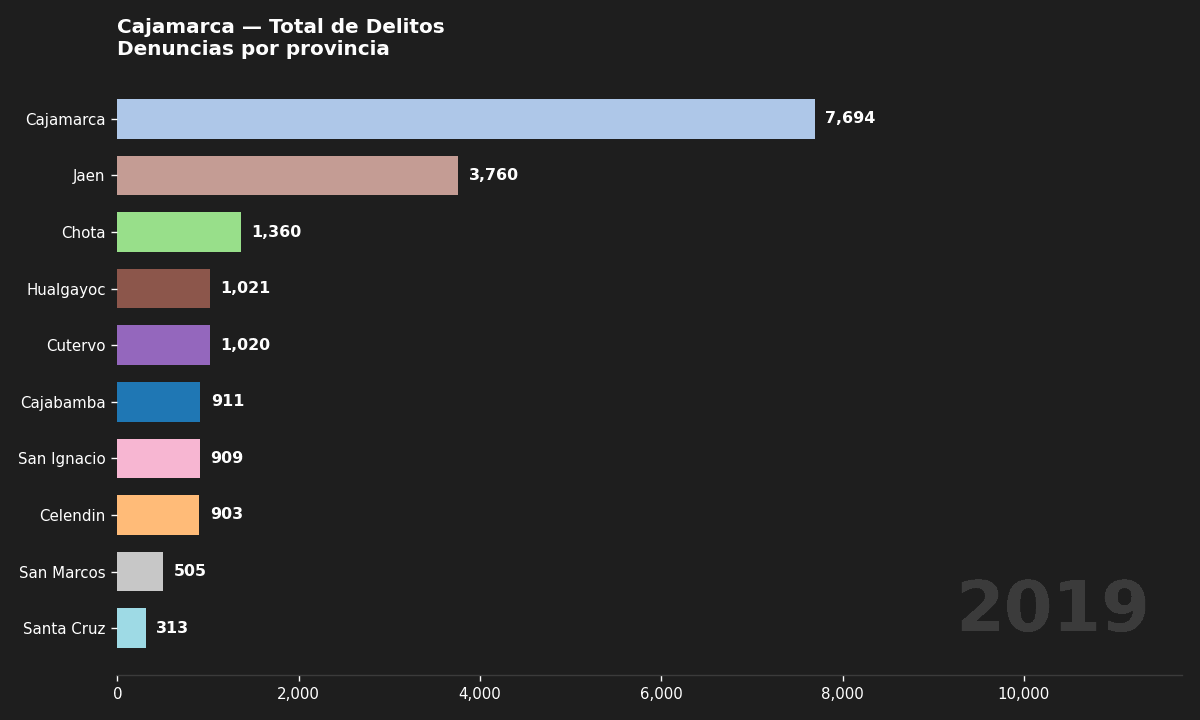

In [ ]:
ruta_total = crear_gif_modalidad(None, 'Total_Denuncias_Cajamarca')
if ruta_total:
    display(Image(filename=ruta_total))

✅ GIF creado exitosamente: gif/Robos_Cajamarca.gif


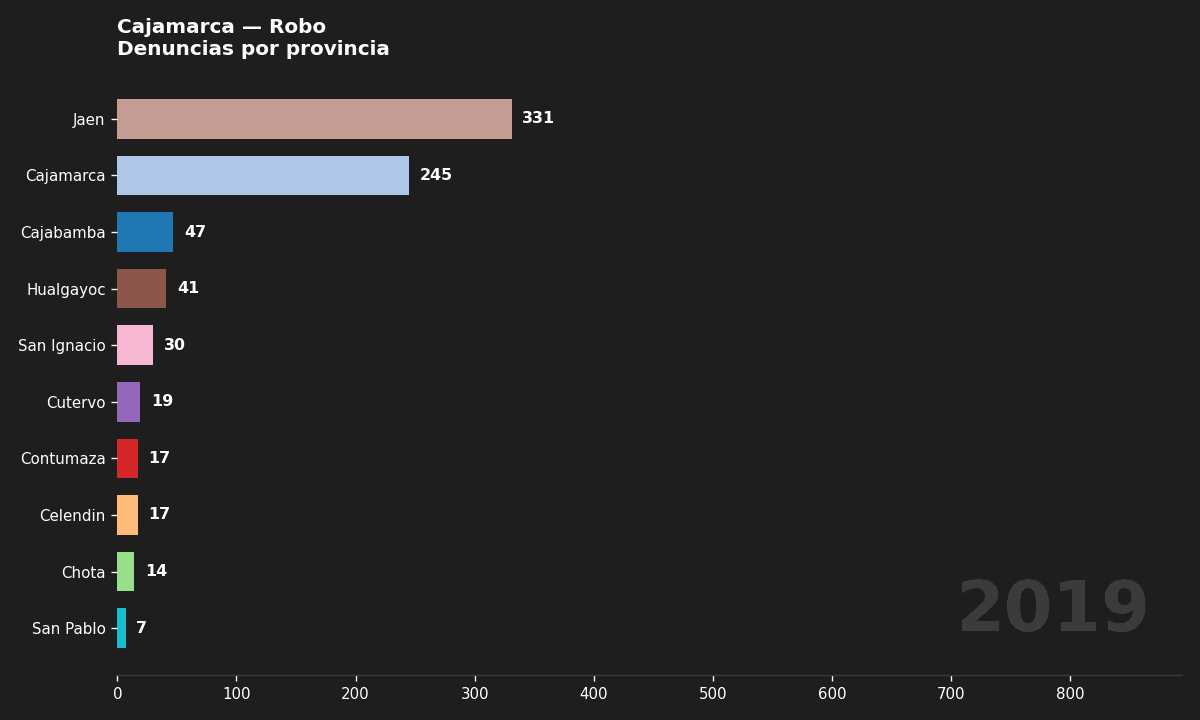

In [ ]:
#  GIF específico para la modalidad de Robo
ruta_robo = crear_gif_modalidad('Robo', 'Robos_Cajamarca')

if ruta_robo:
    display(Image(filename=ruta_robo))

In [ ]:
ruta_extorsion = crear_gif_modalidad('Extorsi', 'Extorsion_Cajamarca')

✅ GIF creado exitosamente: gif/Extorsion_Cajamarca.gif


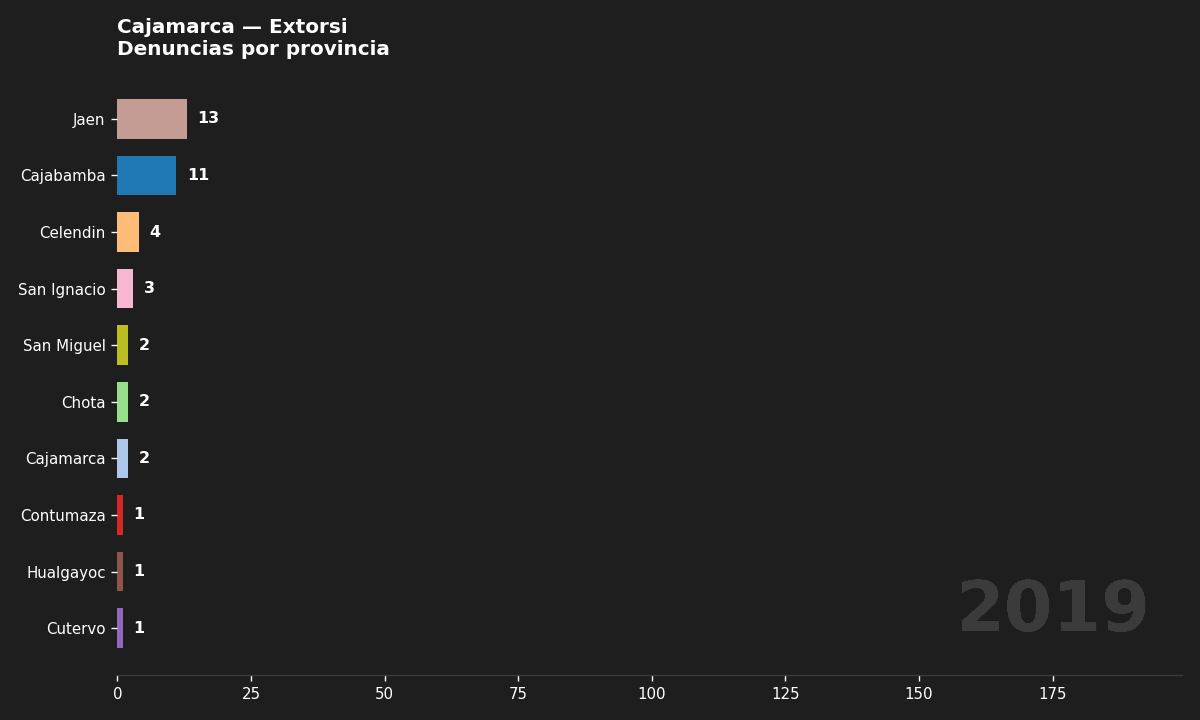

In [ ]:
from IPython.display import Image, display
display(Image(filename=ruta_extorsion))

In [ ]:

import unicodedata

url_geojson = "https://raw.githubusercontent.com/juaneladio/peru-geojson/master/peru_provincial_simple.geojson"
mapa_peru = gpd.read_file(url_geojson)

provincias_cajamarca = df[df['DEPARTAMENTO'].str.upper() == 'CAJAMARCA']['PROV_HECHO'].unique()

provincias_cajamarca_normalized = [unicodedata.normalize('NFKD', p.upper().strip()).encode('ascii', errors='ignore').decode('utf-8') for p in provincias_cajamarca]

mapa_peru['NOMBPROV_NORMALIZED'] = mapa_peru['NOMBPROV'].str.upper().str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')

mapa_cajamarca = mapa_peru[mapa_peru['NOMBPROV_NORMALIZED'].isin(provincias_cajamarca_normalized)].copy()

del mapa_peru['NOMBPROV_NORMALIZED']

mapa_cajamarca['PROV_KEY'] = mapa_cajamarca['NOMBPROV'].str.upper().str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')
df['PROV_KEY'] = df['PROV_HECHO'].str.upper().str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')

AÑOS = sorted(df['ANIO'].unique())

def crear_gif_mapa_geografico(modalidad_filtro, nombre_gif):
    frames = []
    df_filtro = df[df['P_MODALIDADES'].str.contains(modalidad_filtro, case=False, na=False)] if modalidad_filtro else df.copy()

    max_historico = df_filtro.groupby(['ANIO', 'PROV_KEY'])['cantidad'].sum().max()
    vmax = max_historico if pd.notnull(max_historico) else 10

    for año in AÑOS:
        datos_año = df_filtro[df_filtro['ANIO'] == año].groupby('PROV_KEY')['cantidad'].sum().reset_index()
        mapa_año = mapa_cajamarca.merge(datos_año, on='PROV_KEY', how='left')
        mapa_año['cantidad'] = mapa_año['cantidad'].fillna(0)

        fig, ax = plt.subplots(figsize=(10, 10))
        fig.patch.set_facecolor(BG_COLOR)
        ax.set_facecolor(BG_COLOR)

        mapa_año.plot(column='cantidad', cmap='YlOrRd', linewidth=1.2, ax=ax, edgecolor='#0d1b2a', vmin=0, vmax=vmax)

        titulo = modalidad_filtro if modalidad_filtro else 'Todas las Modalidades'
        ax.set_title(f'Mapa Criminal — Cajamarca\n{titulo} ({año})', color=TEXT_COLOR, fontsize=16, fontweight='bold', pad=15)
        ax.axis('off')

        ruta_frame = f'gif/frame_{año}.png'
        plt.savefig(ruta_frame, dpi=120, bbox_inches='tight', facecolor=BG_COLOR)
        plt.close()
        frames.append(ruta_frame)

    if frames:
        imagenes = [imageio.imread(f) for f in frames]
        ruta_gif = f'gif/{nombre_gif}.gif'
        imageio.mimwrite(ruta_gif, imagenes, fps=1.2, loop=0)
        for f in frames: os.remove(f)
        return ruta_gif
    return None

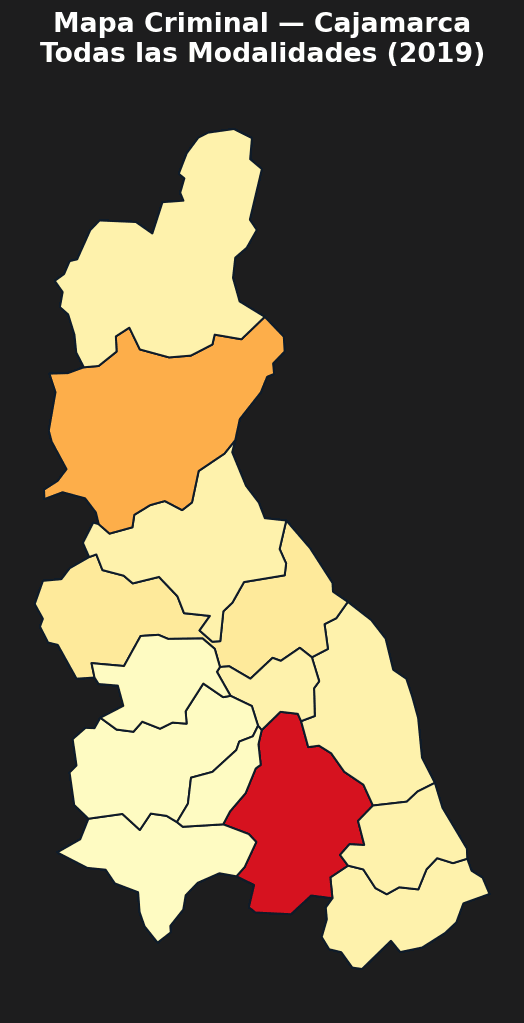

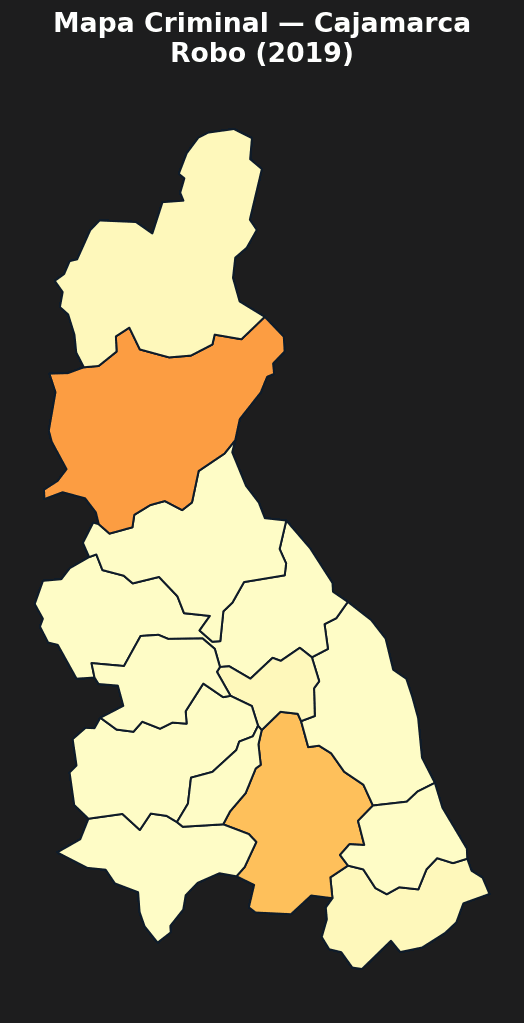

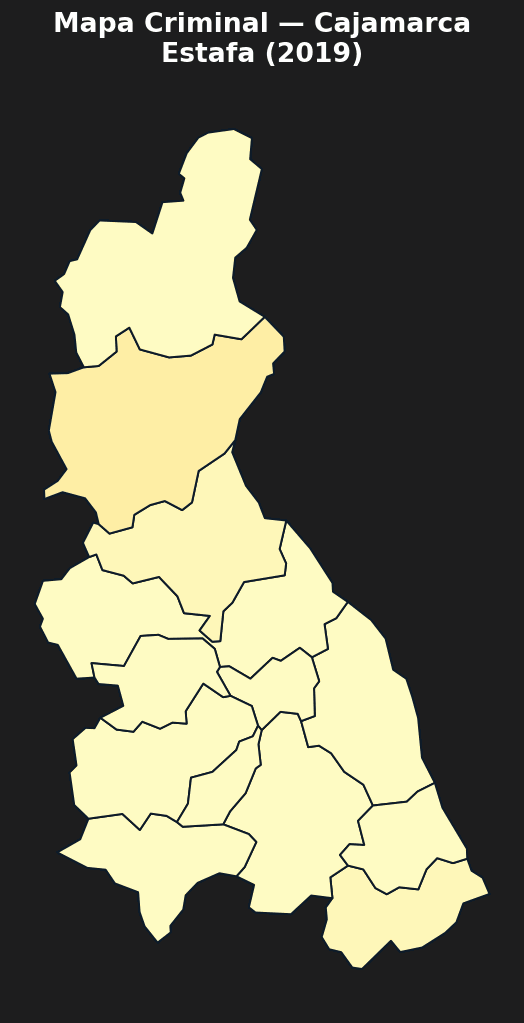

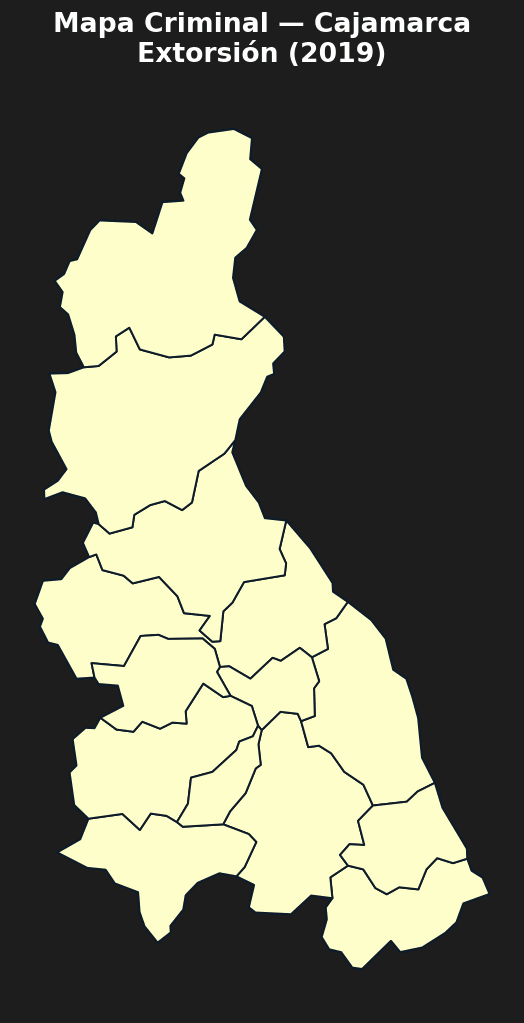

In [ ]:
# Generar mapa total
ruta_total = crear_gif_mapa_geografico(None, 'Mapa_Geo_Total_Cajamarca')
if ruta_total: display(Image(filename=ruta_total))


delitos_clave = ['Robo', 'Estafa', 'Extorsión']
for delito in delitos_clave:
    ruta = crear_gif_mapa_geografico(delito, f'Mapa_Geo_{delito}_Cajamarca')
    if ruta: display(Image(filename=ruta))